# COM6018 - Assignment 1

Student Username: `ACQ23AHT`

## Analysing Carbon Emissions Data

Before attempting the assignment make sure that you have read the accompanying assignment notes document carefully. This explains important details about what is expected and how you will be assessed.

## Loading the data

The data is being read from the file `owid-co2-data.csv` which you must download and store in the same directory as this notebook. Please leave the cell below unchanged. 

In [1]:
import pandas as pd

df = pd.read_csv('owid-co2-data.csv')

Add any further imports that your notebook needs in the cell below. If you are not using any then simply leave the cell blank. Remember, you are only allowed to use modules from the standard Python library, plus pandas, numpy, matplotlib and seaborn.

In [2]:
# SOLUTION
# Imports
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns

## Q1. The growth of CO<sub>2</sub> emissions

*How have CO<sub>2</sub> emissions grown over time?*

The dataset contains entries for countries grouped into four income groups: low, lower-middle, upper-middle and high. i) How have the total annual CO<sub>2</sub> emissions of each income group varied over the years 1950 to 2021? ii) How has the per capita CO<sub>2</sub> emissions (i.e., the emissions per person) of these groups varied over the same period. Comment on how the contribution of each income group is different when measured in terms of total emissions and per capita emissions.

(Add your solution below. Add further markdown and code cells as needed.)

In [3]:
#Checking for Duplicates
df[df.duplicated()].count()

country                        0
year                           0
iso_code                       0
population                     0
gdp                            0
                              ..
temperature_change_from_n2o    0
total_ghg                      0
total_ghg_excluding_lucf       0
trade_co2                      0
trade_co2_share                0
Length: 79, dtype: int64

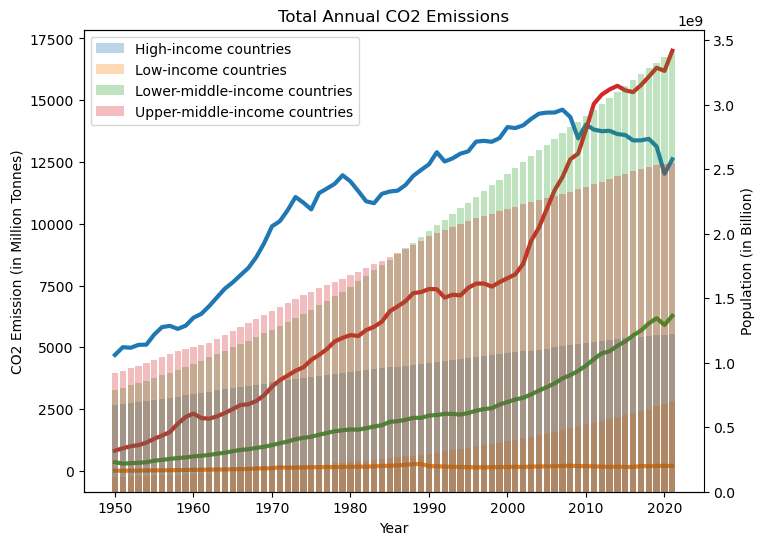

In [4]:
# Q1. i] Total annual CO2 emissions of each income group varied over the years 1950 to 2021
df_co2 = df.copy()

# Removing NA values from the CO2 column
df_co2 = df_co2.dropna(subset = ['co2'])

# Filtering the data with the required values - Income groups & Year
income_group = df_co2[
    (df_co2['country'].isin(['Low-income countries', 'Lower-middle-income countries', 'Upper-middle-income countries', 'High-income countries'])) &
    (df_co2['year'].between(1950,2021))
]

# Removing unrequired columns
income_group = income_group.loc[:,['year', 'population', 'country', 'co2']]

# Grouping the data with respect to countries
groupby1 = income_group.groupby('country')  

# Create a figure with secondary y-axis
fig, ax = plt.subplots(figsize=(8,6))
ax2 = ax.twinx()

# Using Loop to get data from each country group  
for group_name,j in groupby1:
    bars = ax2.bar(j['year'], j['population'], alpha = 0.3, label = group_name)
    line, = ax.plot(j['year'], j['co2'], linewidth = 3)

# PLOTTING
ax2.spines['right'].set_visible(False)

# Add labels and title
ax2.set_ylabel('Population (in Billion)')
ax.set_ylabel('CO2 Emission (in Million Tonnes)')
ax.set_xlabel('Year')
plt.title('Total Annual CO2 Emissions')

# Show the plot
plt.legend(loc='upper left')
plt.show()

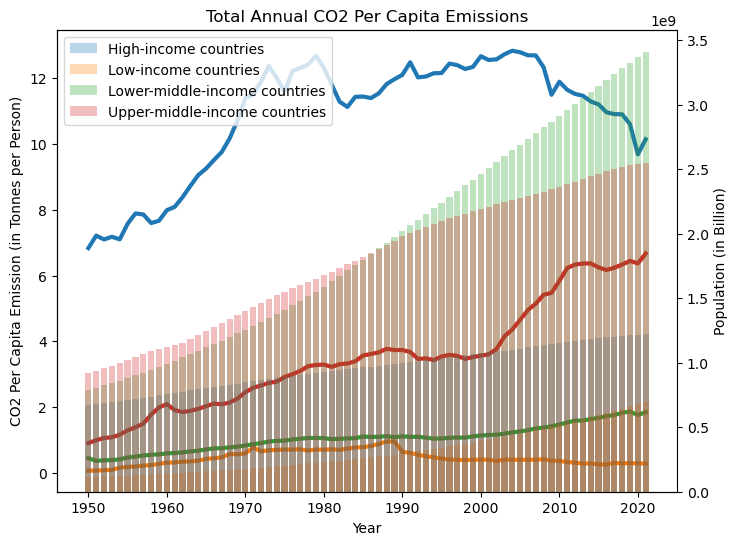

In [5]:
# Q1. ii] Per capita CO2 emissions of these groups varied over the same period
df_co2_pc = df.copy()

# Removing NA values from the CO2 column
df = df_co2_pc.dropna(subset = ['co2_per_capita'])

# Filtering the data with the required values - Income groups & Year
income_group = df_co2_pc[
    (df_co2_pc['country'].isin(['Low-income countries', 'Lower-middle-income countries', 'Upper-middle-income countries', 'High-income countries'])) &
    (df_co2_pc['year'].between(1950,2021))
]

# Removing unrequired columns
income_group = income_group.loc[:,['year', 'population', 'country', 'co2_per_capita']]

# Grouping the data with respect to countries
groupby1 = income_group.groupby('country')  

# Dataframe with year interval of 10 for the Bar plot
popul = income_group[
            (income_group['year'].isin([1950,1960,1970,1980,1990,2000,2010,2020]))
]

# Create a figure with secondary y-axis
fig, ax = plt.subplots(figsize=(8,6))
ax2 = ax.twinx()

# Using Loop to get data from each country group  
for group_name,j in groupby1:
    bars = ax2.bar(j['year'], j['population'], alpha = 0.3, label = group_name)
    line, = ax.plot(j['year'], j['co2_per_capita'], linewidth = 3)

# PLOTTING
ax2.spines['right'].set_visible(False)

# Adding labels and title
ax2.set_ylabel('Population (in Billion)')
ax.set_ylabel('CO2 Per Capita Emission (in Tonnes per Person)')
ax.set_xlabel('Year')
plt.title('Total Annual CO2 Per Capita Emissions')

# Show the plot
plt.legend(loc='upper left')
plt.show()

## Comment on how the contribution of each income group is different when measured in terms of total emissions and per capita emissions.

The line plot illustrates the per capita CO<sub>2</sub> emissions of the groups of countries according to income. The bar plot on the secondary y-axis shows the population of groups over the years. The contribution of each income group is dependent on several factors like population growth, industrialization, sustainable development, etc. 

i] Low Income Countries - We can notice that the overall CO<sub>2</sub> emissions of countries in this group have been close to 0 throughout the given years. This can be attributed to factors such as limited energy consumption, industrialization and less carbon emitting activites. However, when we compare per capita CO<sub>2</sub> emissions, we can find minor spikes around the year 1970 and 1990 noteworthy, which might be associated with increased industrialization. There has been a slight increase in the population of these countries from the end of the 19th century, but despite the spikes, their relative contribution is significantly less when compared to the higher income groups.

ii] Lower-Middle Income Countries - The population growth curve for this set of countries is the highest. The increase in CO<sub>2</sub> emissions can be directly associated with the sharp rise in the population from late 1900s, as the CO<sub>2</sub> emissions per person in the second graph show only a slight increase. In terms of global contribution, the graph shows a gradual increase in the CO<sub>2</sub> emissions, on the other hand, the relatively stable per capita CO<sub>2</sub> emissions indicate that individuals are not emitting significantly moore CO<sub>2</sub> possibly due to improvements in technologies and energy effeciency. It's crucial to remember that even though emissions per person may not be rising dramatically, overall emissions still contribute considerably. This shows that these nations need to keep up their efforts to reduce emissions and advance in sustainable development.

iii] Upper-Middle Income Countries - For this group of nations the total CO<sub>2</sub> emissions have an alarming increase along with a rapid rate of population growth. The emission increase has been particularly notable from the start of the year 2000, which signifies rapid expansion in industrialization, transportation and energy consumption. The per capita CO<sub>2</sub> emissions have only gradually increased, despite a significant increase in overall CO<sub>2</sub> emissions. This might be the result of factors like increased energy efficiency, technological developments or popoulation growth. This group has the most substantial impact on the global climate due to significantly higher emission output. This data highlights a severe need for efforts to reduce CO<sub>2</sub> emissions.    

iv] High Income Countries - When it comes to the emissions for the high income group, we can observe a more intricate pattern that begins with large increases, followed by brief decreases before beginning to decline around the year 2010. There is only a subtle growth in population. The per capita CO<sub>2</sub> emission has followed a similar trend. Compared to other groups, this group consistently have higher CO<sub>2</sub> emissions, both in total and per capita. But the decline reflects that they have successfully improved energy effeciency, adopted cleaner technologies and other sustainable developments.

## Q2. The share of CO2 emissions by country over time.

*Which countries have the highest CO<sub>2</sub> emissions?*

Compare the share of global carbon emissions for the top 5 emitting countries as a proportion of the total world emissions. Make separate plots for the years 1960, 1990 and 2020. Make a similar set of plots but normalised in a way that accounts for the population of each country. Note, all the plots should appear in the same figure.

Comment on how the top 5 emitting countries have changed over time and how the top 5 emitting countries change when you normalise for population.

(Add your solution below. Add further markdown and code cells as needed.)

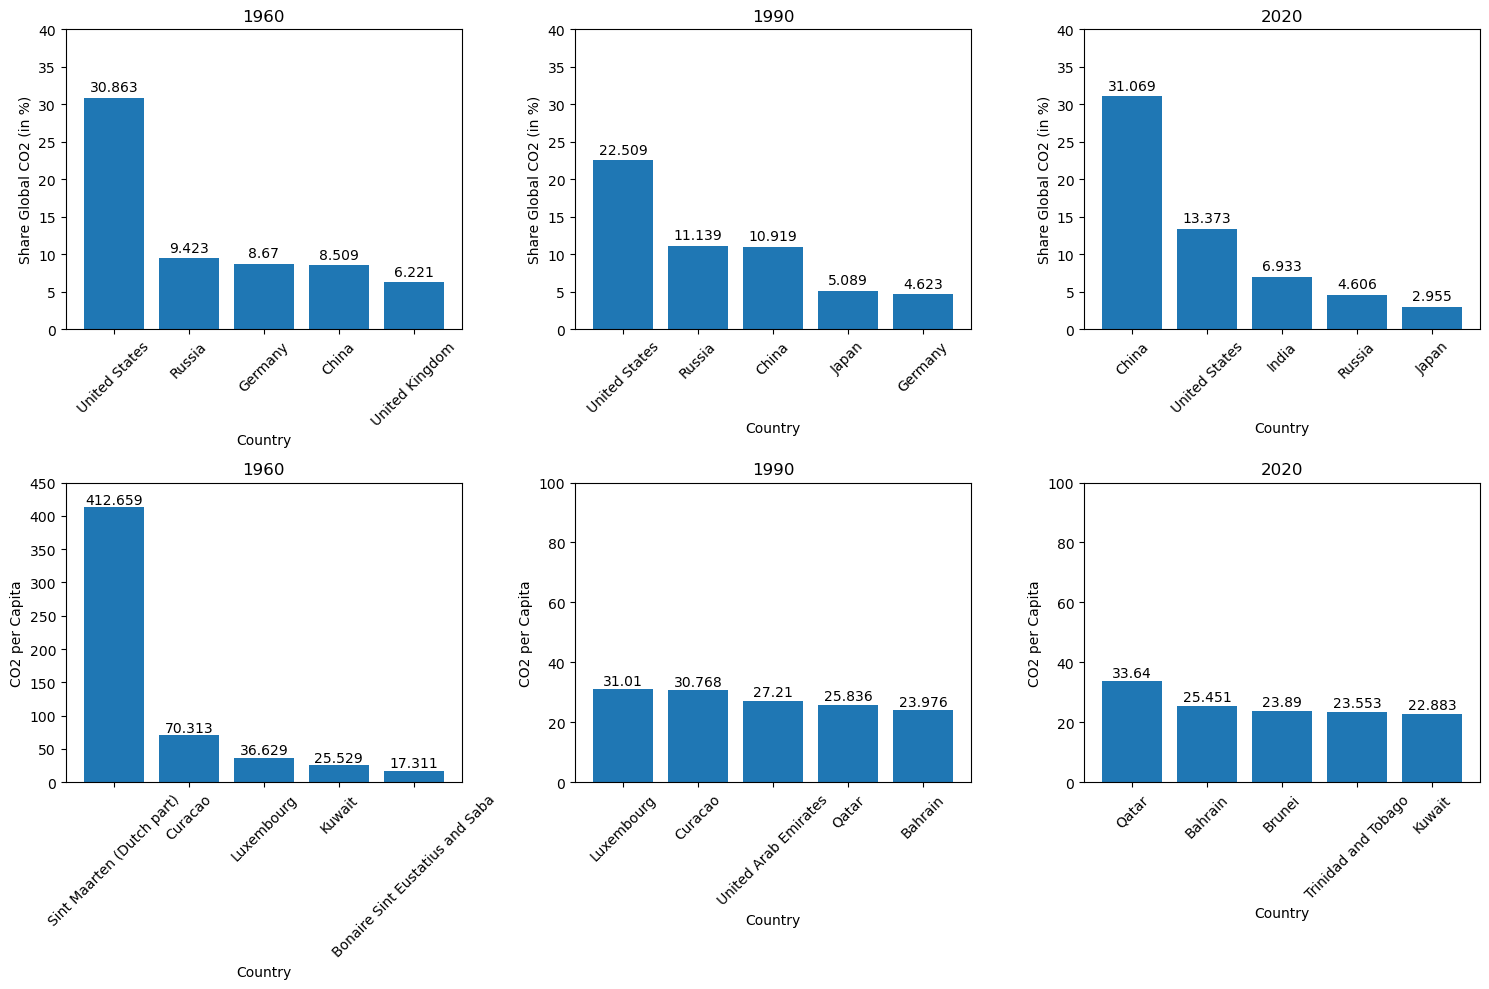

In [8]:
# Q2]
df_co2_year = df.copy()

# Remove NA values from co2, co2_per_capita, iso_code columns
df_co2_year = df_co2_year.dropna(subset = ['share_global_co2','co2_per_capita','iso_code'])

#Extracting specific years and including only countries
year_group = df_co2_year[
    (df_co2_year['year'].isin([1960,1990,2020])) &
    (df_co2_year['iso_code'] != '')
]

#Sorting for highest values of co2 emissions for each year
sorted_df = year_group.sort_values(by=['year','share_global_co2'], ascending=[True,False])
sorted_df_capita = year_group.sort_values(by=['year','co2_per_capita'], ascending=[True,False])

#Extracting specific columns
sorted_df = sorted_df.loc[:,['year', 'population', 'country', 'share_global_co2']]
sorted_df_capita = sorted_df_capita.loc[:,['year', 'population', 'country', 'co2_per_capita']]

#Filtering the top 5 values for each year
groupby2 = sorted_df.groupby('year').head(5)
groupby2_capita = sorted_df_capita.groupby('year').head(5)

# Defining Figure and Axes for the Subplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

df_1960 = groupby2[groupby2['year'] == 1960]
df_1990 = groupby2[groupby2['year'] == 1990]
df_2020 = groupby2[groupby2['year'] == 2020]

df_capita_1960 = groupby2_capita[groupby2_capita['year'] == 1960]
df_capita_1990 = groupby2_capita[groupby2_capita['year'] == 1990]
df_capita_2020 = groupby2_capita[groupby2_capita['year'] == 2020]


#Defining each Axes
#For Axes[0,0]
axes[0,0].bar(df_1960['country'], df_1960['share_global_co2'])
axes[0,0].set_xlabel('Country')
axes[0,0].set_ylabel('Share Global CO2 (in %)')
axes[0,0].set_title('1960')
axes[0,0].set_ylim(0,40)
axes[0,0].tick_params(axis='x', labelrotation=45)
# Adding labels on top of the bars
for i, value in enumerate(df_1960['share_global_co2']):
    axes[0,0].text(i, value + 0.5, str(value), ha='center', va='bottom')

#For Axes[1,0]
axes[1,0].bar(df_capita_1960['country'], df_capita_1960['co2_per_capita'])
axes[1,0].set_xlabel('Country')
axes[1,0].set_ylabel('CO2 per Capita')
axes[1,0].set_title('1960')
axes[1,0].set_ylim(0,450)
axes[1,0].tick_params(axis='x', labelrotation=45)
# Adding labels on top of the bars
for i, value in enumerate(df_capita_1960['co2_per_capita']):
    axes[1,0].text(i, value + 0.5, str(value), ha='center', va='bottom')

#For Axes[0,1]
axes[0,1].bar(df_1990['country'], df_1990['share_global_co2'])
axes[0,1].set_xlabel('Country')
axes[0,1].set_ylabel('Share Global CO2 (in %)')
axes[0,1].set_title('1990')
axes[0,1].set_ylim(0,40)
# Add labels on top of the bars
for i, value in enumerate(df_1990['share_global_co2']):
    axes[0,1].text(i, value + 0.5, str(value), ha='center', va='bottom')
axes[0,1].tick_params(axis='x', labelrotation=45)

#For Axes[1,1]
axes[1,1].bar(df_capita_1990['country'], df_capita_1990['co2_per_capita'])
axes[1,1].set_xlabel('Country')
axes[1,1].set_ylabel('CO2 per Capita')
axes[1,1].set_title('1990')
axes[1,1].set_ylim(0,100)
axes[1,1].tick_params(axis='x', labelrotation=45)
# Add labels on top of the bars
for i, value in enumerate(df_capita_1990['co2_per_capita']):
    axes[1,1].text(i, value + 0.5, str(value), ha='center', va='bottom')

#For Axes[0,0]
axes[0,2].bar(df_2020['country'], df_2020['share_global_co2'])
axes[0,2].set_xlabel('Country')
axes[0,2].set_ylabel('Share Global CO2 (in %)')
axes[0,2].set_title('2020')
axes[0,2].set_ylim(0,40)
axes[0,2].tick_params(axis='x', labelrotation=45)
# Add labels on top of the bars
for i, value in enumerate(df_2020['share_global_co2']):
    axes[0,2].text(i, value + 0.5, str(value), ha='center', va='bottom')

#For Axes[0,0]
axes[1,2].bar(df_capita_2020['country'], df_capita_2020['co2_per_capita'])
axes[1,2].set_xlabel('Country')
axes[1,2].set_ylabel('CO2 per Capita')
axes[1,2].set_title('2020')
axes[1,2].set_ylim(0,100)
axes[1,2].tick_params(axis='x', labelrotation=45)
# Add labels on top of the bars
for i, value in enumerate(df_capita_2020['co2_per_capita']):
    axes[1,2].text(i, value + 0.5, str(value), ha='center', va='bottom')

# Adjust layout and show the plot
plt.tight_layout() 
plt.show()


## Comment on how the top 5 emitting countries have changed over time and how the top 5 emitting countries change when you normalise for population.

i] Share of Global Carbon emission - United States has been the highest CO<sub>2</sub> emitting country for the years 1960 and 1990, changing from 30.8 to 22.5 percentage of global production-based emissions of CO<sub>2</sub> , after which it came down to second highest in the year 2020 at 31.0%. China's CO<sub>2</sub> emission levels have substantially increased from the fourth position in 1960 at only 8.5%, to 3rd in 1990, at 10.9%, and finally placing it highest in CO<sub>2</sub> emissions in the year 2020 at 31.0%. Russia stayed at the second highest for the first two years and then became the 4th highest in 2020. 
We can infer that countries like United States, Germany and Russia have demonstrated a decline in their proportion of the world's CO<sub>2</sub> emission levels, conversely, countries like China, India and Japan are evidently occupying higher positions in the charts. This may be a result of variables like population growth, increased energy consumption, or changes in the economies of these nations.

ii] CO<sub>2</sub> per Capita - To normalise the data that accounts for the population of each country, we can consider the per capita CO<sub>2</sub> emission of each country. We observe that countries in the top 5 share of percentage of global production-based emissions of CO₂ are not the countries with the highest per capita CO<sub>2</sub> emissions. Sint Maarten has recorded the highest emission in the year 1960, followed by Curacao, that stayed the second highest in the year 1990. Luxembourg's emissions went from being the third highest in 1960 to the highest in 1990, but they sucessfully managed to minimise emissions by the year 2020. The data for Kuwait between 1960 and 2020 indicates that although the country's emissions initially decreased around the year 1990, they eventually increased back up. Around the late 19th century, Qatar and Bahrain per person emisions have increased significantly making them the top emittors of CO<sub>2</sub> per capita in 2020. This may be due to a number of factors, including increased energy consumption, urbanisation, and fast industrialization—all of which individually have the potential to result in higher emissions. United Arab Emirates, Brunei and Trinidad and Tobago are other countries to have reached the top 5 countries.

Every nation's global CO<sub>2</sub> emissions are largely determined by its population. Despite having low CO<sub>2</sub> emissions per person, cumulative CO<sub>2</sub> emissions contribute a larger share of country's global carbon emissions. The significance of comprehending regional patterns and the influence of economic growth on carbon emissions is also emphasised. 

## Q3. The link between GDP and CO<sub>2</sub> emissions

*Do countries with high GDP always have high per capita CO<sub>2</sub> emissions.* 

Plot the per capita CO<sub>2</sub> emissions against the GDP per capita for each country. Design your plot so that the size of the marker is proportional to the population of the country. Only consider countries with a population of at leat 5 million people. 

Compare these plots for the year 1978, 1998 and 2018.  Comment on the relationship between the two variables and how it has changed over time.

(Add your solution below. Add further markdown and code cells as needed.)

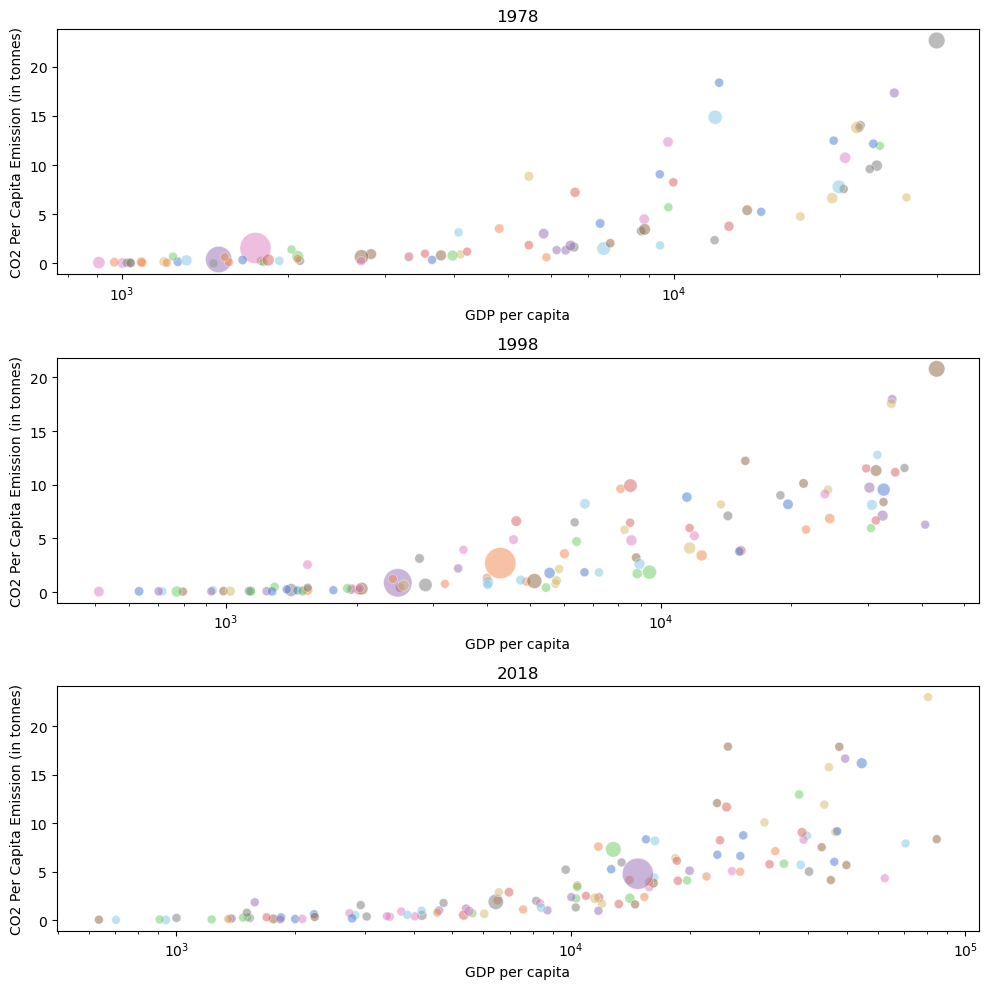

In [11]:
# Q3] Per capita CO2 emissions against the GDP per capita
df_gdp = df.copy()

# Removing NA values from the CO2_per_capita column
df_gdp = df_gdp.dropna(subset = ['co2_per_capita'])

#Filtering the data for the required year, population and including only countries
gdp_group = df_gdp[
    (df_gdp['year'].isin([1978,1998,2018])) &
    (df_gdp['population'] > 5000000) &
    (df_gdp['iso_code'] != '')
]

#Adding column for GDP_per_capita
gdp_group = gdp_group.dropna(subset = ['gdp'])
gdp_group = gdp_group.loc[:,['year', 'co2_per_capita', 'population', 'country', 'gdp']]
gdp_group['gdp_per_capita'] = gdp_group['gdp'] / gdp_group['population']

# Defining Figure and Axes for the plot
fix, axes = plt.subplots(3, figsize=(10,10))

df_1978 = gdp_group[gdp_group['year'] == 1978]
df_1998 = gdp_group[gdp_group['year'] == 1998]
df_2018 = gdp_group[gdp_group['year'] == 2018]

#Plotting graph using Seaborn Scatterplot
sns.scatterplot(
            data = df_1978, x = 'gdp_per_capita', y = 'co2_per_capita', 
            hue = 'country', size = 'population',
            sizes=(40,500), alpha = 0.5, palette = 'muted',
            ax=axes[0], legend=False
            )
sns.scatterplot(
            data = df_1998, x = 'gdp_per_capita', y = 'co2_per_capita', 
            hue = 'country', size = 'population',
            sizes=(40,500), alpha = 0.5, palette = 'muted',
            ax=axes[1], legend=False
            )
sns.scatterplot(
            data = df_2018, x = 'gdp_per_capita', y = 'co2_per_capita', 
            hue = 'country', size = 'population',
            sizes=(40,500), alpha = 0.5, palette = 'muted',
            ax=axes[2], legend=False
            )

#Defining Labels
axes[0].set_xlabel('GDP per capita')
axes[1].set_xlabel('GDP per capita')
axes[2].set_xlabel('GDP per capita')

axes[0].set_ylabel('CO2 Per Capita Emission (in tonnes)')
axes[1].set_ylabel('CO2 Per Capita Emission (in tonnes)')
axes[2].set_ylabel('CO2 Per Capita Emission (in tonnes)')
#(in Tonnes per Person)

#Scaling Y-Axis
axes[0].set_title('1978')
axes[0].set_xscale('log')
axes[1].set_title('1998')
axes[1].set_xscale('log')
axes[2].set_title('2018')
axes[2].set_xscale('log')

# Adjust layout
plt.tight_layout()
plt.show()

## Compare these plots for the year 1978, 1998 and 2018.  Comment on the relationship between the two variables and how it has changed over time.

In the year 1978, we may observe a positive corrlelation between GDP per capita and per capita CO<sub>2</sub> emissions. There are lower values of GDP per capita concentrated around 0 per capita CO<sub>2</sub> emissions with countries having slightly higher population plots. This is due to many countries in 1978 were likely less industrialized due to low economy. With the increasing GDP per capita, we can observe that per capita CO<sub>2</sub> emissions graph gradually rises to reach 5 to 15 tonnes per person but accounted for in less populous countries. 
Similar trend can be observed in 1998, with the values concentrated in the middle of the scale on x axis, where the per capita CO<sub>2</sub> emissions is close to 0 and slightly higher population plots. The per capita CO<sub>2</sub> emissions are more dispersed before reaching 10<sup>4</sup> for per capita GDP. We can infer that growing industrialization, technological improvements and higher economy has resulted to a higher emission of CO<sub>2</sub> emissions per person. Steps should be taken to mitigate the alarming growth rate of CO<sub>2</sub> emissions.  
The graph shows that in the year 2018, a higher percentage of population can be found having values of per capita CO<sub>2</sub> emissions close from 5 to 15 tonnes per person. A majority of countries have a higher economical standings due to high per capita GDP, which shows that several factors like efficient technologies, increased awareness, government policies, etc contributing to similar data that was recorded in previous year's data.

Countries with high GDP per capita have relatively higher per capita CO<sub>2</sub> emissions, meaning they are positively correlated. This is because a developed economy with a higher GDP has more industrial growth, energy consumption, and transportation requirements. Although, over time, the transition towards safer methods and efficient systems have come into play to mitigate exponential rise in overall CO<sub>2</sub> emissions.   

## Q4. The development of wealth inequality over time.

*Has the distribution of wealth across countries become more or less equal over time?*

Make a plot that compares the distribution of GDP per capita across the countries in the world and 10-yearly intervals from 1950 to 2020.  Comment on how the distribution has changed over time.

(Add your solution below. Add further markdown and code cells as needed.)

Text(0, 0.5, 'GDP Per Capita')

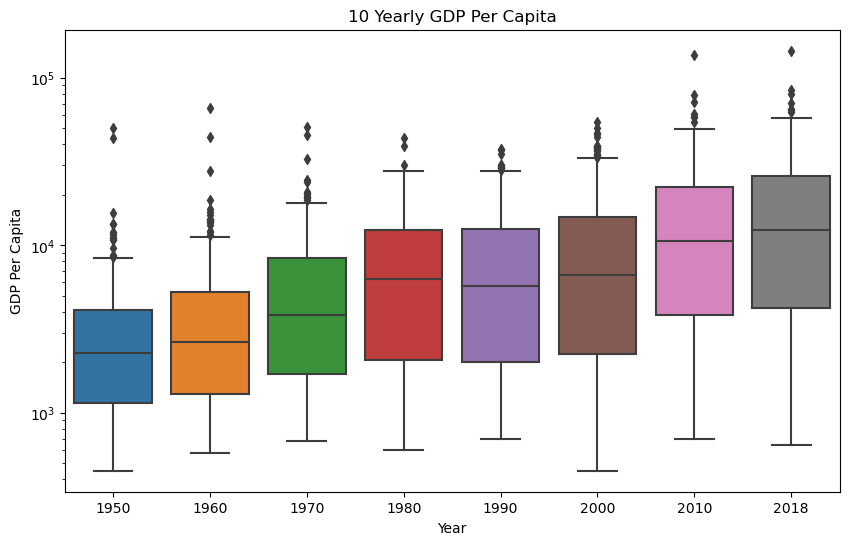

In [12]:
df_gdp_10 = df.copy()

#Filtering the data for the required year and including only countries
gdp_10 = df_gdp_10[
    (df_gdp_10['year'].isin([1950,1960,1970,1980,1990, 2000,2010,2018])) &
    (df_gdp_10['iso_code'] != '')
]

gdp_10 = gdp_10.dropna(subset = ['gdp', 'iso_code'])

#Extracting only requiired columns 
gdp_10 = gdp_10.loc[:,['year', 'co2_per_capita', 'population', 'country', 'gdp']]
gdp_10['gdp_per_capita'] = gdp_10['gdp'] / gdp_10['population']

#Defining the figure
plt.figure(figsize=(10, 6))

sns.boxplot(
    data = gdp_10, x='year', y='gdp_per_capita'
    )

plt.title('10 Yearly GDP Per Capita')
plt.yscale('log')
plt.xlabel('Year')
plt.ylabel('GDP Per Capita')

## Comment on how the distribution has changed over time.
This grpah illustrates how the GDP per capita across the countries in the world changed over a 10 yearly period from 1950 to 2018. It functions as a statistical record of the world's economic health. Thus we can see that there has been an overall growth in the GDP per capita over the years. We can ignore the outliers as they have little impact on the graphs. The interquartile range shows a subtle increase in size. There is a noticeable peak in the value of GDP per capita in the year 1980, otherwise the graph has a gradual ascent. With the duration of time, the whiskers of each reading have also increased in size, highest in the year 2000. The median GDP per capita is highest in the year 2018. 

## Reminder

Before submitting your notebook make sure that it runs correctly from the beginning by selecting "Restart and run all" from the Kernel menu. Make sure that you save your notebook using the name `COM6018-assignment1-<your-student-username>.ipynb`. For example, if your username is 'ac1jpb' then your notebook should be named `COM6018-assignment1-ac1jpb.ipynb`. To submit, follow the instruction in the accompanying assignment instructions document. For late submission, unless there are extenuating circumstances, standard lateness penalties will be applied.